In [1]:
import numpy as np 
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import linregress
import matplotlib.pyplot as plt
from uncertainties import ufloat
import math
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

# Konstanten für Energieberechnung
hc_eV_nm = 1240  # h*c in eV*nm
h = 6.62607015e-34  # Plancksches Wirkungsquantum in Js (angepasst)
m_0 = 9.10938356e-31  # Elektronenmasse in kg (angepasst)
c= 299792458  # Lichtgeschwindigkeit in m/s (angepasst)
h_quer = h / (2 * np.pi)  # Reduziertes Plancksches Wirkungsquantum in Js (angepasst)


C:\Users\Celina\AppData\Local\Temp\ipykernel_2920\1939435997.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df_ref= pd.read_csv(r"20-03-26\Ref.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
#print(df_ref.head())

files= [r"20-03-26\2-15.dat", r"20-03-26\2-30.dat", r"20-03-26\2-45.dat", r"20-03-26\2-60.dat", r"20-03-26\2-75.dat" ]
längen= [ufloat(0.15, 0.005), ufloat(0.30, 0.005), ufloat(0.45, 0.005), ufloat(0.60, 0.005), ufloat(0.75, 0.005)] # in m , UNsicherheit von 0,005 m
unit_längen= "m"
iris3= [ufloat(10,0), ufloat(13,0), ufloat(16,0)]
unit_iris= "mm"

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


## Aufgabe 2: 

wenn alle peaks gefunden sind, können Kreuze entfernt werden und bild gesaved werden

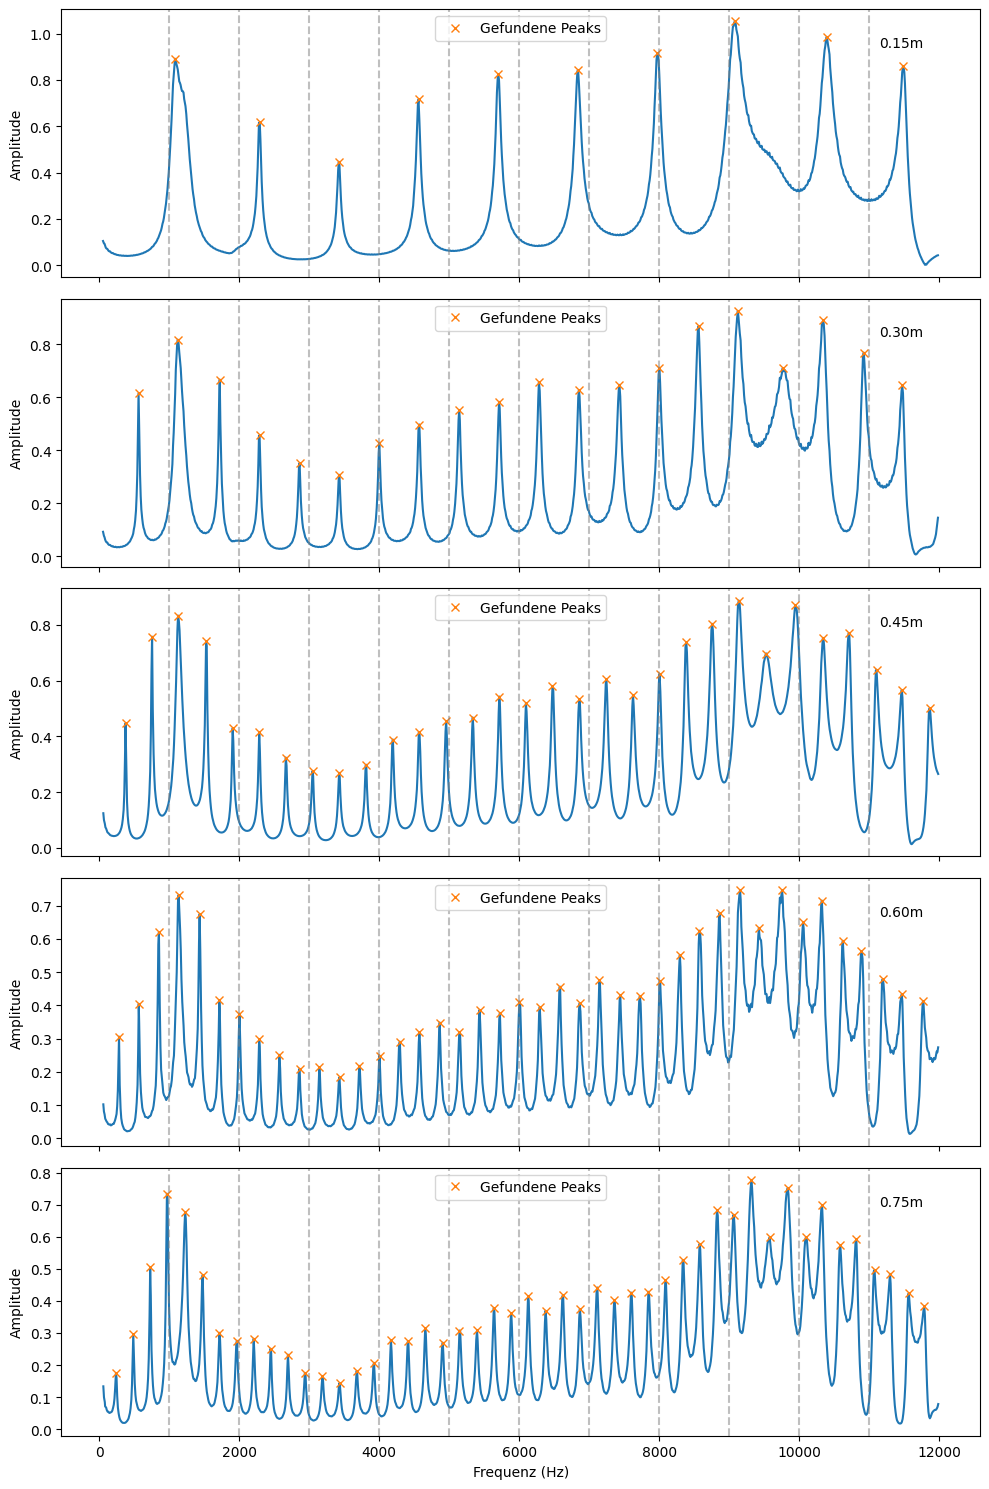

[array([1083.48954+/-5.0, 2294.44268+/-5.0, 3424.11657+/-5.0,
       4563.03012+/-5.0, 5704.25648+/-5.0, 6843.11302+/-5.0,
       7974.85902+/-5.0, 9083.4418+/-5.0, 10395.52402+/-5.0,
       11485.08651+/-5.0], dtype=object), array([562.79696+/-5.0, 1123.35449+/-5.0, 1722.79882+/-5.0,
       2291.95412+/-5.0, 2863.92301+/-5.0, 3433.42003+/-5.0,
       4002.88585+/-5.0, 4574.57452+/-5.0, 5144.20426+/-5.0,
       5713.73249+/-5.0, 6283.13983+/-5.0, 6854.8021+/-5.0,
       7433.77144+/-5.0, 8005.30581+/-5.0, 8565.39457+/-5.0,
       9125.59598+/-5.0, 9765.36839+/-5.0, 10344.26704+/-5.0,
       10925.11236+/-5.0, 11473.58355+/-5.0], dtype=object), array([376.71834+/-5.0, 756.28148+/-5.0, 1127.31937+/-5.0,
       1527.73109+/-5.0, 1907.27182+/-5.0, 2286.93562+/-5.0,
       2666.78696+/-5.0, 3048.55322+/-5.0, 3428.10808+/-5.0,
       3816.8925+/-5.0, 4196.74904+/-5.0, 4567.28188+/-5.0,
       4958.19773+/-5.0, 5337.81509+/-5.0, 5717.5582+/-5.0,
       6097.30872+/-5.0, 6477.1556+/-5.0, 6858.

In [100]:
#Aufgabe 1 

from matplotlib.pyplot import axes
from matplotlib import axes
from scipy.optimize import curve_fit


def find_resonance_frequencies(files, height= 0.05, prominence= 0.02, rel_heigth= None, width = None): # height, prominence for better peak finding, when applying on other spectrum

    peaks_all_f= []
    peaks_index_all= []
    frequency_all= []
    amplitude_all= []
    
    for i, file in enumerate(files): 
        df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
        #print(df.head())
        
        frequency= df["Frequenz"]
        frequency_all.append(frequency)
        amplitude= df["Amplitude"] / df_ref["Amplitude"] # Normierung der Amplitude mit der Referenz
        amplitude_all.append(amplitude)
        
        peaks, properties = find_peaks(
            amplitude,
            height=height,        # minimale Peak-Höhe (anpassen!)
            prominence=prominence,   # wie stark der Peak herausragt
            distance=10,
            rel_height= rel_heigth,
            width=width
            )
        #  mit den Parametern werden alle Peaks gefunden! 

        
        peaks_all_f.append (np.array([ufloat(frequency[peak], 5) for peak in peaks]))
        peaks_index_all.append(peaks)
        
    return peaks_all_f, peaks_index_all, frequency_all, amplitude_all    


def plt_spectrum_with_optpeaks(peaks_all_f, peaks_index_all, frequency_all, amplitude_all, label, unit, plot_peaks= True ):
    
    fig, axes = plt.subplots(len(peaks_index_all), 1, figsize=(10, 3* len(peaks_index_all)), sharex=True)
    
    for i, peaks in enumerate(peaks_index_all):
        axes[i].plot(frequency_all[i], amplitude_all[i])
        axes[i].text(0.89, 0.9, f"{label[i].nominal_value:.2f}{unit}", transform=axes[i].transAxes, verticalalignment='top')
        if plot_peaks:
            axes[i].plot(frequency_all[i][peaks], amplitude_all[i][peaks], "x", label="Gefundene Peaks")
        axes[i].set_ylabel("Amplitude")
        axes[i].legend(loc= "upper center")
        
    reference_lines = np.linspace(1000,11000, 11)
    for ax in axes:
        for line in reference_lines:
            ax.axvline(line, linestyle="--", color="gray", alpha=0.5) 
            
    plt.xlabel("Frequenz (Hz)")
    plt.tight_layout()
    plt.show()


peaks_all_f, peaks_index_all, frequency_all, amplitude_all = find_resonance_frequencies(files)

plt_spectrum_with_optpeaks(peaks_all_f, peaks_index_all, frequency_all, amplitude_all, label= längen, unit= "m")

print(peaks_all_f)

c= 345+/-5
Fehler aus Fit: 5.116294007363732
c= 344.4+/-0.8
Fehler aus Fit: 0.76219360936656
c= 344.35+/-0.29
Fehler aus Fit: 0.2949952886951002
c= 344.23+/-0.16
Fehler aus Fit: 0.15771834388292877
c= 368.85+/-0.11
Fehler aus Fit: 0.11418243285313769


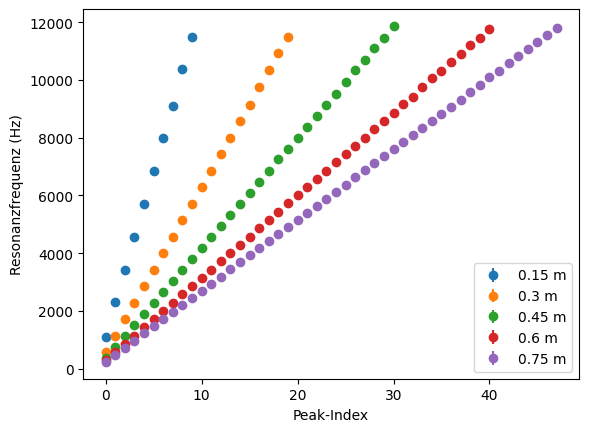

Mittlere Schallgeschwindigkeit: 349.46+/-1.04 m/s


In [36]:
c= [] # array für alle berechneten Schallgeschwindigkeiten, arrays in array für jede Länge einen



for i, peaks in enumerate(peaks_all_f):
    #print(peaks)
    x= np.arange(len(peaks))
    y= np.array([p.nominal_value for p in peaks])
    slope, intercept, r_value, p_value, std_err = linregress(x, y) #lineare Regresssion
    plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o', label=f"{längen[i].nominal_value} m")#: Lineare Regression: R²={r_value**2:.4f}")
    plt.xlabel("Peak-Index")
    plt.ylabel("Resonanzfrequenz (Hz)")
    
    c.append(ufloat(slope * 2 * längen[i].nominal_value, std_err) ) #Steigung * 2 * Länge (in m) = c
    
    print(f"c= {c[-1]}")
    print(f"Fehler aus Fit: {std_err}")
plt.legend()
plt.show()
    
c_mean= 1/len(c) * np.sum(c)
print(f"Mittlere Schallgeschwindigkeit: {c_mean:.2f} m/s")

In [99]:
# 2 theoretische Werte

c_theo= 343  # Schallgeschwindigkeit in Luft bei 20°C in m/s
f_theo= []

for i, L in enumerate(längen):
    f= []
    print(f"theoretische Referenzfrequenzen für L= {L} m:")
    print(f"Anzahl der Peaks: {len(peaks_all_f[i])}")
    for n in np.arange(1, len(peaks_all_f[i])):  #je nach Länge, unterschiedliche Anzahl von Peaks
        f_t= n* c_theo / (2 * L) 
        f.append(f_t)
        print(f"{f_t:.2f} Hz")
    f_theo.append(f)
    
#print(f_theo)

theoretische Referenzfrequenzen für L= 0.150+/-0.005 m:
Anzahl der Peaks: 10
1143.33+/-38.11 Hz
2286.67+/-76.22 Hz
3430.00+/-114.33 Hz
4573.33+/-152.44 Hz
5716.67+/-190.56 Hz
6860.00+/-228.67 Hz
8003.33+/-266.78 Hz
9146.67+/-304.89 Hz
10290.00+/-343.00 Hz
theoretische Referenzfrequenzen für L= 0.300+/-0.005 m:
Anzahl der Peaks: 20
571.67+/-9.53 Hz
1143.33+/-19.06 Hz
1715.00+/-28.58 Hz
2286.67+/-38.11 Hz
2858.33+/-47.64 Hz
3430.00+/-57.17 Hz
4001.67+/-66.69 Hz
4573.33+/-76.22 Hz
5145.00+/-85.75 Hz
5716.67+/-95.28 Hz
6288.33+/-104.81 Hz
6860.00+/-114.33 Hz
7431.67+/-123.86 Hz
8003.33+/-133.39 Hz
8575.00+/-142.92 Hz
9146.67+/-152.44 Hz
9718.33+/-161.97 Hz
10290.00+/-171.50 Hz
10861.67+/-181.03 Hz
theoretische Referenzfrequenzen für L= 0.450+/-0.005 m:
Anzahl der Peaks: 31
381.11+/-4.23 Hz
762.22+/-8.47 Hz
1143.33+/-12.70 Hz
1524.44+/-16.94 Hz
1905.56+/-21.17 Hz
2286.67+/-25.41 Hz
2667.78+/-29.64 Hz
3048.89+/-33.88 Hz
3430.00+/-38.11 Hz
3811.11+/-42.35 Hz
4192.22+/-46.58 Hz
4573.33+/-50.81

In [ ]:
# 2 Abweichung der experimentellen Werte von den theoretischen ReferenzFREQUENZEN

print("Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:")
for i in range(len(peaks_all_f)):
    print( f"für L= {längen[i].nominal_value:.2f} m:")
    for b,t in (zip(peaks_all_f[i], f_theo[i])): # array mit den Frequenzen für Länge i
        #print( b, t)
        pro_abw = abs(b - t) / t *100
        print( pro_abw)

Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:
für L= 0.15 m:
5.2+/-3.2
0.3+/-3.4
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.4+/-3.3
0.7+/-3.3
1.0+/-3.4
für L= 0.30 m:
1.6+/-1.9
1.7+/-1.7
0.5+/-1.7
0.2+/-1.7
0.2+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.1+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.2+/-1.7
0.5+/-1.7
0.5+/-1.7
0.6+/-1.7
für L= 0.45 m:
1.2+/-1.7
0.8+/-1.3
1.4+/-1.2
0.2+/-1.2
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.2+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.4+/-1.1
0.6+/-1.1
0.4+/-1.1
0.5+/-1.1
0.3+/-1.1
für L= 0.60 m:
0.7+/-1.9
1.0+/-1.2
0.4+/-1.0
0.7+/-0.9
0.4+/-0.9
0.1+/-0.9
0.2+/-0.9
0.0+/-0.9
0.1+/-0.9
0.2+/-0.9
0.1+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0

C:\Users\Celina\AppData\Local\Temp\ipykernel_14432\2760256305.py:8: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  pro_abw = abs(b - t) / t *100


## Aufgabe 3:

[array([306.6253+/-5.0, 616.33206+/-5.0, 918.51545+/-5.0, 1237.61358+/-5.0,
       1527.99216+/-5.0, 1807.06171+/-5.0, 2067.21007+/-5.0,
       2268.44063+/-5.0, 3468.08386+/-5.0, 3667.55092+/-5.0,
       3897.39872+/-5.0, 4157.37251+/-5.0, 4398.44668+/-5.0,
       4618.69686+/-5.0, 4817.90585+/-5.0, 4968.01969+/-5.0,
       6807.63049+/-5.0, 6938.49248+/-5.0, 7098.04208+/-5.0,
       7297.50926+/-5.0, 7489.19313+/-5.0, 7657.95441+/-5.0,
       7798.5251+/-5.0, 10219.05493+/-5.0, 10357.78711+/-5.0,
       10638.58998+/-5.0, 10948.13627+/-5.0], dtype=object), array([333.84997+/-5.0, 664.75777+/-5.0, 995.34727+/-5.0,
       1356.05091+/-5.0, 1686.14533+/-5.0, 2005.26166+/-5.0,
       2325.91884+/-5.0, 2607.43801+/-5.0, 3357.29565+/-5.0,
       3507.31054+/-5.0, 3786.20114+/-5.0, 4095.60944+/-5.0,
       4416.36195+/-5.0, 4716.39364+/-5.0, 5016.41624+/-5.0,
       5285.89859+/-5.0, 5506.31692+/-5.0, 6806.66644+/-5.0,
       7017.58531+/-5.0, 7266.23543+/-5.0, 7547.13217+/-5.0,
       7816

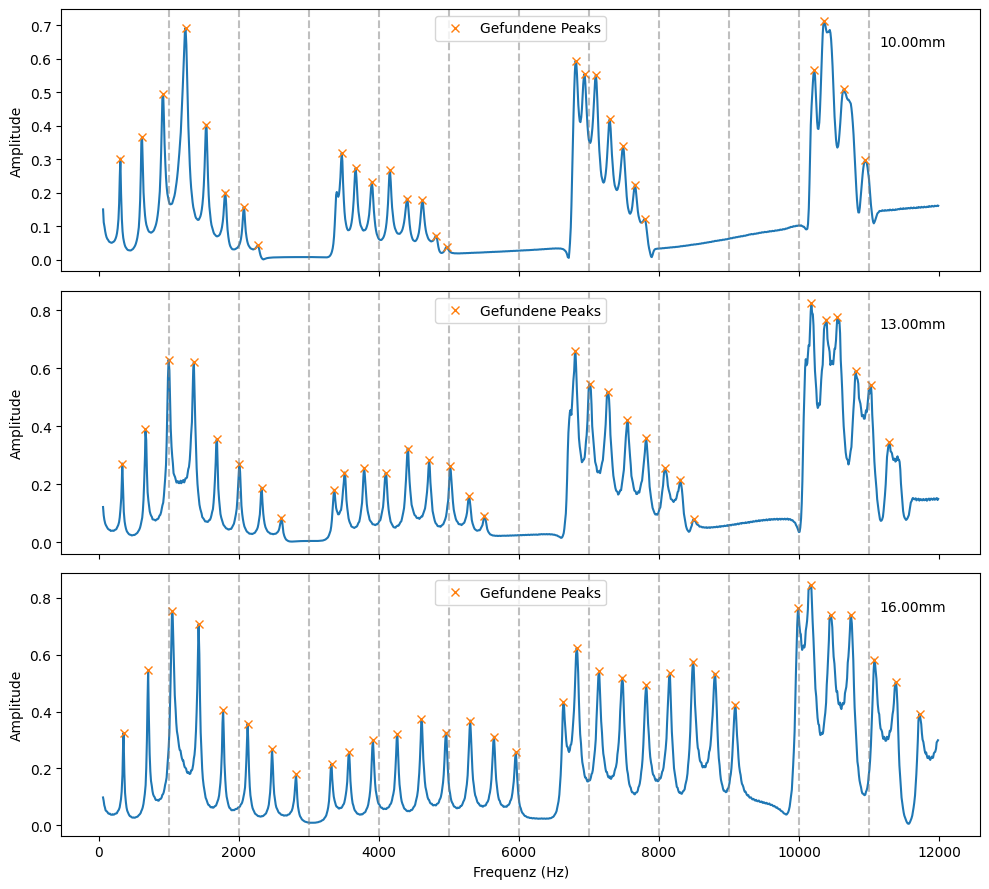

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


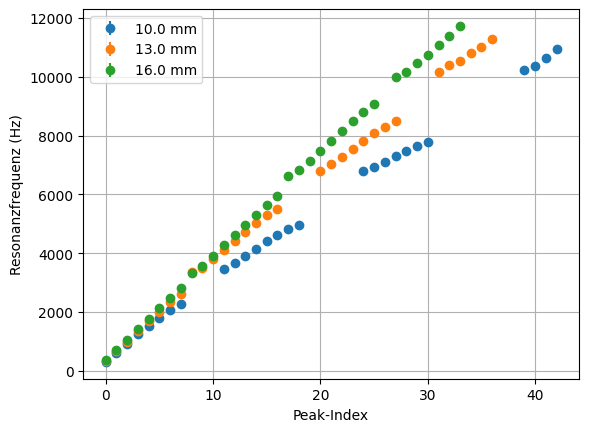

In [107]:
# 3 Bestimmung Resonanzfrequnzen für verschiedene Iris Blenden bei L= 45cm 

files3= [r"20-03-26\3-10mm.dat", r"20-03-26\3-13mm.dat", r"20-03-26\3-16mm.dat"]

peaks_all_f3, peaks_index_all3, frequency_all3, amplitude_all3= find_resonance_frequencies(files3, height=0.0005, rel_heigth= 0.2, prominence=0.009, width= (1,20))


peaks3_all_raw= peaks_all_f3.copy()

#weil nicht alle peaks erkannt werden: 
peaks_all_f3[0]= np.delete(peaks_all_f3[0], -5) # plateau bei kurz nach 10kHz löschen 
peaks_index_all3[0]= np.delete(peaks_index_all3[0], -5) # index des gelöschten peaks auch löschen

peaks_all_f3[1]= np.delete(peaks_all_f3[1],-1) # letzen bei 13mm löschen
peaks_index_all3[1]= np.delete(peaks_index_all3[1],-1) # index des gelöschten peaks auch löschen
#hier werden nichtdie richtigen Peaks geplottet
print(peaks_all_f3)
plt_spectrum_with_optpeaks(peaks_all_f3, peaks_index_all3, frequency_all3, amplitude_all3, label= iris3, unit= "mm", plot_peaks= True)

# leere Stellen einfügen, damit Bandlücke sichtbar wird
nan_stellen_10= [8,9,10,19,20,21,22,23,31,32,33,34,35,36,37,38]
for i in nan_stellen_10: 
    peaks_all_f3[0] = np.insert(peaks_all_f3[0],[i],[ufloat(np.nan,0)])

nan_stellen_13= [17,18,19,28,29,30]
for i in nan_stellen_13: 
    peaks_all_f3[1] = np.insert(peaks_all_f3[1],[i],[ufloat(np.nan,0)])
    
nan_stellen_16= [26]
for i in nan_stellen_16: 
    peaks_all_f3[2] = np.insert(peaks_all_f3[2],[i],[ufloat(np.nan,0)])


# Resonanzfrequnezen gegen Index
def frequency_gegen_index(peaks_all, label, unit):
    for i, peaks in enumerate(peaks_all):
        x= np.arange(len(peaks))
        y= np.array([p.nominal_value for p in peaks])
        plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o', label= f"{label[i].nominal_value} {unit}")
        plt.xlabel("Peak-Index")
        plt.ylabel("Resonanzfrequenz (Hz)")
        plt.legend()
        plt.grid()

frequency_gegen_index(peaks_all_f3, iris3, unit_iris)
plt.show()

### Dispersionsrelation (Aufgabe 5)

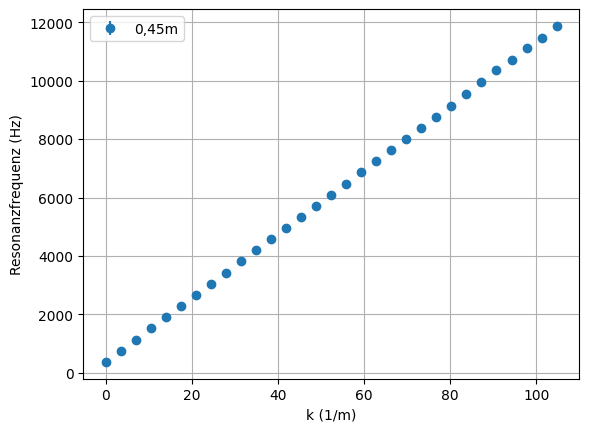

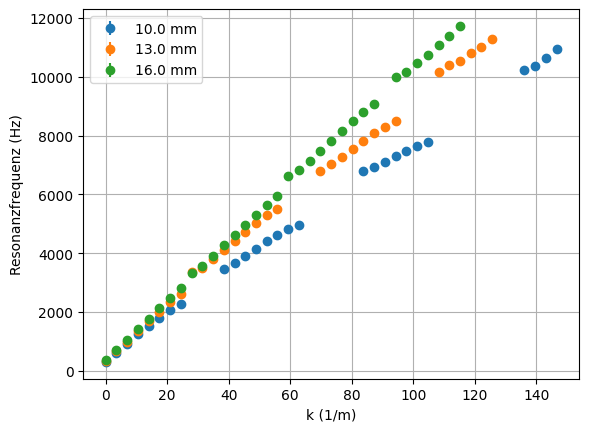

In [106]:
# w(k) = n* c* pi / (2L)



n= np.arange(len(peaks_all_f[2]))
x=n * np.pi /(2* 0.45)
y= np.array([peaks.nominal_value for peaks in peaks_all_f[2]])
plt.errorbar(x, y, yerr= [peaks.std_dev for peaks in peaks_all_f[2]], fmt='o', label= f"0,45m")
plt.xlabel("k (1/m)")
plt.ylabel("Resonanzfrequenz (Hz)")
plt.legend()
plt.grid()
plt.show()

for i, peaks in enumerate(peaks_all_f3):
        n= np.arange(len(peaks))
        x=n * np.pi /(2* 0.45)
        y= np.array([p.nominal_value for p in peaks])
        
        plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o', label= f"{iris3[i].nominal_value} mm")
        plt.xlabel("k (1/m)")
        plt.ylabel("Resonanzfrequenz (Hz)")
        plt.legend()
        plt.grid()
plt.show()

### Aufgabe 4

[array([977.09277+/-5.0, 2017.37093+/-5.0, 3367.2092+/-5.0,
       4117.05935+/-5.0, 5028.58069+/-5.0, 6727.52431+/-5.0,
       7297.22316+/-5.0, 8107.63082+/-5.0, 10207.43459+/-5.0,
       10697.31564+/-5.0, 11327.45839+/-5.0], dtype=object), array([499.5619+/-5.0, 989.56304+/-5.0, 1519.41752+/-5.0,
       2009.28793+/-5.0, 2479.52424+/-5.0, 3359.28229+/-5.0,
       3649.43853+/-5.0, 4099.42758+/-5.0, 4569.7527+/-5.0,
       5019.70926+/-5.0, 5409.38697+/-5.0, 6719.42309+/-5.0,
       6899.56321+/-5.0, 7269.62312+/-5.0, 7689.47183+/-5.0,
       8089.64544+/-5.0, 8379.84416+/-5.0, 10109.58822+/-5.0,
       10329.69617+/-5.0, 10589.75346+/-5.0, 10959.8112+/-5.0,
       11259.80382+/-5.0, 11559.76191+/-5.0], dtype=object), array([333.84997+/-5.0, 664.75777+/-5.0, 995.34727+/-5.0,
       1356.05091+/-5.0, 1686.14533+/-5.0, 2005.26166+/-5.0,
       2325.91884+/-5.0, 2607.43801+/-5.0, 3357.29565+/-5.0,
       3507.31054+/-5.0, 3786.20114+/-5.0, 4095.60944+/-5.0,
       4416.36195+/-5.0, 471

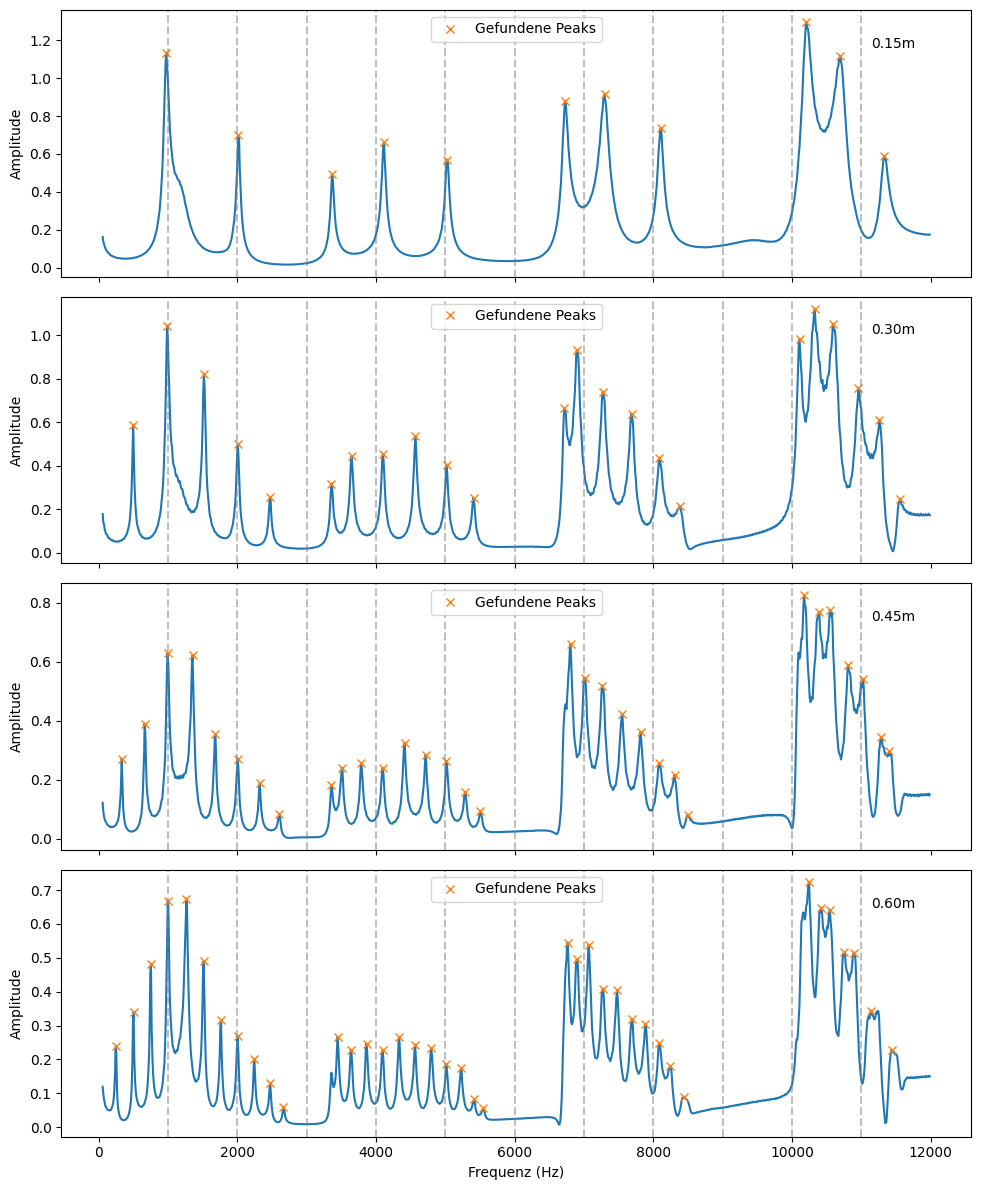

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


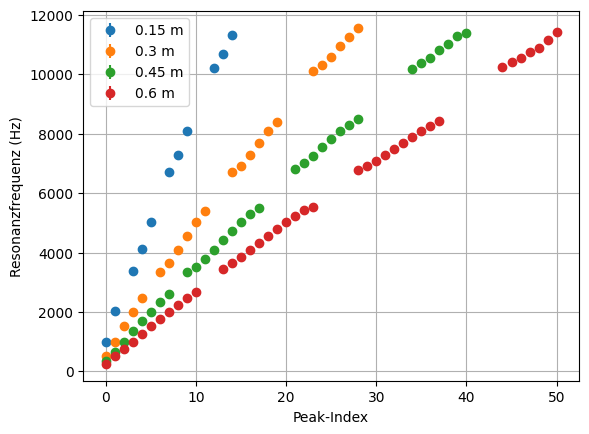

In [108]:
files4= [r"20-03-26\4-15.dat", r"20-03-26\4-30.dat", r"20-03-26\3-13mm.dat", r"20-03-26\4-60.dat"]


peaks_all_f4, peaks_index_all4, frequency_all4, amplitude_all4= find_resonance_frequencies(files4, prominence=0.01)#, width= (1,20))#prominence= 0.01


peaks_all_f4[1]= np.delete(peaks_all_f4[1],-5)
peaks_index_all4[1]= np.delete(peaks_index_all4[1],-5)
#peaks_all_f4[1]= np.delete(peaks_all_f4[1],-1)
#peaks_index_all4[1]= np.delete(peaks_index_all4[1],-1)

peaks_all_f4[2]= np.delete(peaks_all_f4[2],-8)
peaks_index_all4[2]= np.delete(peaks_index_all4[2],-8)

print(peaks_all_f4)

plt_spectrum_with_optpeaks(peaks_all_f4, peaks_index_all4, frequency_all4, amplitude_all4, label= längen, unit= "m", plot_peaks= True)

# leere Stellen einfügen, damit Bandlücke sichtbar wird
nan_stellen_15= [2,6,10,11]
for i in nan_stellen_15: 
    peaks_all_f4[0] = np.insert(peaks_all_f4[0],[i],[ufloat(np.nan,0)])

nan_stellen_30= [5,12,13,20,21,22]
for i in nan_stellen_30: 
    peaks_all_f4[1] = np.insert(peaks_all_f4[1],[i],[ufloat(np.nan,0)])
    
nan_stellen_45= [8,18,19,20,29,30,31,32,33]
for i in nan_stellen_45: 
    peaks_all_f4[2] = np.insert(peaks_all_f4[2],[i],[ufloat(np.nan,0)])
    
nan_stellen_60= [11,12,24,25,26,27,38,39,40,41,42,43]
for i in nan_stellen_60: 
    peaks_all_f4[3] = np.insert(peaks_all_f4[3],[i],[ufloat(np.nan,0)])

frequency_gegen_index(peaks_all_f4, längen, unit_längen)
plt.grid()
plt.show()

### Dispersionsrelation 

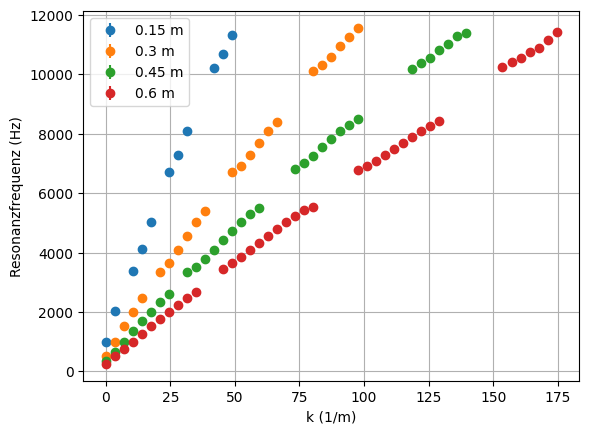

In [ ]:
for i, peaks in enumerate(peaks_all_f4[:4]):
        n= np.arange(len(peaks))
        x=n * np.pi /(2* 0.45)
        y= np.array([p.nominal_value for p in peaks])
        
        plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o', label= f"{längen[i].nominal_value} m")
        plt.xlabel("k (1/m)")
        plt.ylabel("Resonanzfrequenz (Hz)")
plt.grid()
plt.legend()
plt.show()

## Aufgabe 6
### Dispersionsrelation mit Brillouin-Zonen für L= 0.45m und d= 10mm

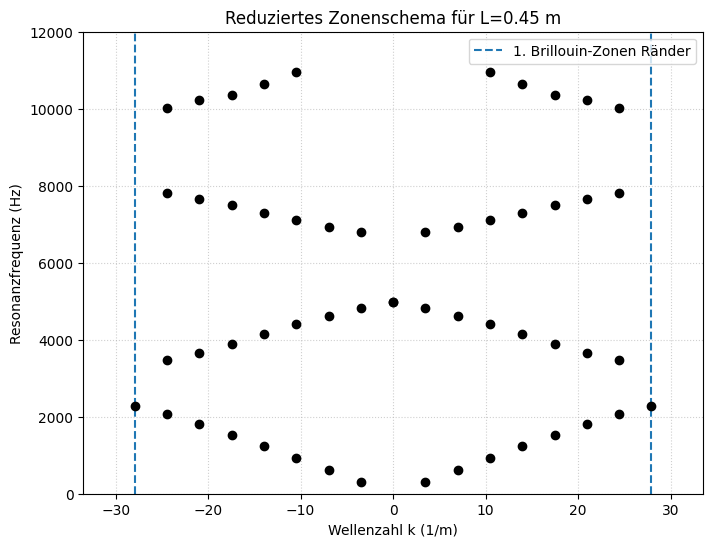

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Daten vorbereiten ---
data6 = peaks3_all_raw[0] 
# Wichtig: Keine Null manuell am Anfang von data6 einfügen!
y = np.array([p.nominal_value for p in data6])
yerr = np.array([p.std_dev for p in data6])

# --- 2. Korrektur der Modenzahlen ---
# Wir starten bei 1 statt 0, damit kein Punkt auf der k=0 Achse liegt
n = np.arange(1, len(data6) + 1)
n_corrected = np.copy(n)

# Da im 3. Band (ca. 6000-8000 Hz) ein Peak fehlt (nur 7 statt 8 Punkte),
# müssen alle folgenden Peaks um einen Zähler nach rechts rücken.
# Dadurch landet der erste Punkt des 4. Bandes exakt auf n=25 (Zonenrand).
n_corrected[y > 9000] += 1 

# Physikalische Parameter
L = 0.45
shift = 0 # Falls ein globaler Offset nötig wäre
x = n_corrected * np.pi / (2 * L) - shift

# --- 3. Transformation ins reduzierte Zonenschema ---
# Die Brillouin-Zonengrenze liegt exakt nach 8 Moden
k_B = 8 * np.pi / (2 * L)

# Die Modulo-Faltung: Bringt k-Werte in den Bereich [0, k_B]
# Durch die Korrektur oben landet n=25 nun bei k = 25*pi/(2L).
# Die Faltung spiegelt dies korrekt an den Zonenrändern.
x_folded = np.abs((x + k_B) % (2 * k_B) - k_B)

# Symmetrisches Bild erzeugen (von -k_B bis +k_B)
x_red_sym = np.concatenate((x_folded, -x_folded))
y_sym = np.concatenate((y, y))
yerr_sym = np.concatenate((yerr, yerr))

# --- 4. Plotten ---
plt.figure(figsize=(8, 6))

plt.errorbar(x_red_sym, y_sym, yerr=yerr_sym, fmt='o', color="black")
plt.vlines([-k_B, k_B], 0, 12000, linestyles="--", label="1. Brillouin-Zonen Ränder", linewidth=1.5)

plt.xlabel("Wellenzahl k (1/m)")
plt.ylabel("Resonanzfrequenz (Hz)")
plt.ylim(0, 12000)
plt.xlim(-k_B * 1.2, k_B * 1.2) 

plt.title("Reduziertes Zonenschema für L=0.45 m")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc= "best")

plt.show()

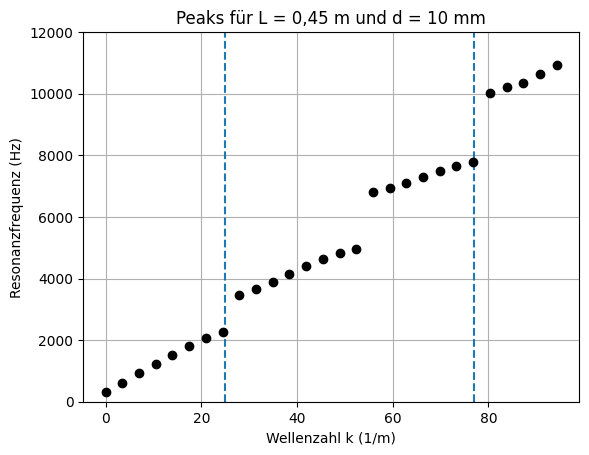

data6 29
1 [nan+/-0 306.6253+/-5.0 616.33206+/-5.0 918.51545+/-5.0 1237.61358+/-5.0
 1527.99216+/-5.0 1807.06171+/-5.0 2067.21007+/-5.0 2268.44063+/-5.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0]
29
[0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 2268.44063+/-5.0 2067.21007+/-5.0 1807.06171+/-5.0
 1527.99216+/-5.0 1237.61358+/-5.0 918.51545+/-5.0 616.33206+/-5.0
 306.6253+/-5.0 nan+/-0]


ValueError: x and y must be the same size

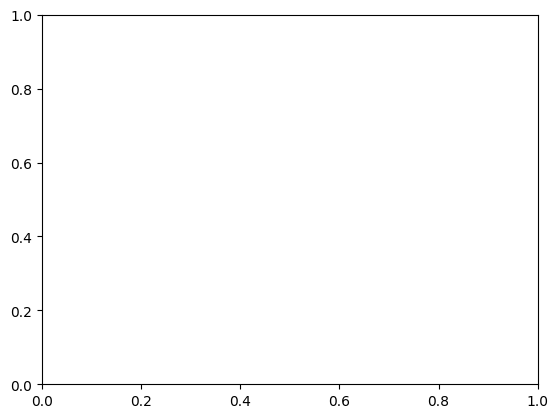

In [123]:
data6= peaks3_all_raw[0]
shift=0
n= np.arange(len(data6))
x=n * np.pi /(2* 0.45)-shift
y= np.array([p.nominal_value for p in data6])

plt.errorbar(x, y, yerr= [p.std_dev for p in data6], fmt='o', color="black")
plt.vlines([25-shift, 77-shift],0, 12000, linestyles="--")

plt.xlabel("Wellenzahl k (1/m)")
plt.ylabel("Resonanzfrequenz (Hz)")
plt.ylim(0,12000)
plt.title(f"Peaks für L = 0,45 m und d = 10 mm")
plt.grid()
plt.show()  

data6= np.insert(data6, 0, ufloat(np.nan, 0))
print("data6",len(data6))
m= np.arange(len(data6))
xb=m * np.pi /(2* 0.45)-shift
#print(len(data6))
eins= np.concatenate((data6[:9],np.zeros(20)))
print("1", eins)
print(len(eins))
zwei= data6[9:17]
#print(zwei)
#print(len(zwei))
drei= data6[17:24]
#print(drei)
#print(len(drei))
vier= data6[24:]
#print(vier)
#print(len(vier))

eins_links= eins[::-1]
print(eins_links)
unten= np.concatenate((eins_links, eins))


shift= 28
plt.scatter(np.arange(len(data6))-shift, [u for u in unten])
plt.show()

'''
data6 = np.insert(data6, 16, ufloat(np.nan, 0))

n = np.arange(len(data6))
k = n * np.pi / (2 * 0.45) - shift

# --- Frequenzen + Fehler ---
y = np.array([p.nominal_value for p in data6])
yerr = np.array([p.std_dev for p in data6])

# --- Brillouin-Zonen-Grenzen ---
k_left = 28 - shift
k_right = 80.5 - shift

k_center = (k_left + k_right) / 2
half_width = (k_right - k_left) / 2

# --- Reduziertes Zonenschema ---
k_shifted = k - k_center

# Zonenindex bestimmen
zone_index = np.floor((k_shifted + half_width) / (2 * half_width))

# In Zone falten
k_mod = (k_shifted + half_width) % (2 * half_width) - half_width

# Jede zweite Zone spiegeln → ergibt Bandstruktur
k_reduced = np.where(zone_index % 2 == 0, k_mod, -k_mod)

# --- Plot ---
plt.errorbar(
    k_reduced,
    y,
    yerr=yerr,
    fmt='o',
    color="black"
)

# Brillouin-Zonen-Grenzen
plt.vlines([-half_width, half_width], 0, 12000, linestyles="--")

plt.xlabel("Wellenzahl k (1/m)")
plt.ylabel("Resonanzfrequenz (Hz)")
plt.ylim(0, 12000)
plt.title("Reduziertes Zonenschema")
plt.grid()

plt.tight_layout()
plt.show()



n= np.arange(len(data6))
x=n * np.pi /(2* 0.45)-shift
y= np.array([p.nominal_value for p in data6])

breite= np.abs(28-shift-(80.5-shift))
print(breite)

plt.errorbar(x, y, yerr= [p.std_dev for p in data6], fmt='o')
plt.vlines([28-shift, 80.5-shift],0, 12000, linestyles="--")

unten_rechts= [np.zeros]
unten_rechts= np.copy(y[:7])

plt.xlabel("k (1/m)")
plt.ylabel("Resonanzfrequenz (Hz)")
plt.ylim(0,12000)
plt.title(f"Peaks für L = 0,45 m und d = 10 mm")
plt.grid()
plt.show()  '''

## Aufgabe 7 Zustandsdichte

### für Werte aus Aufgabe 3  

27 27


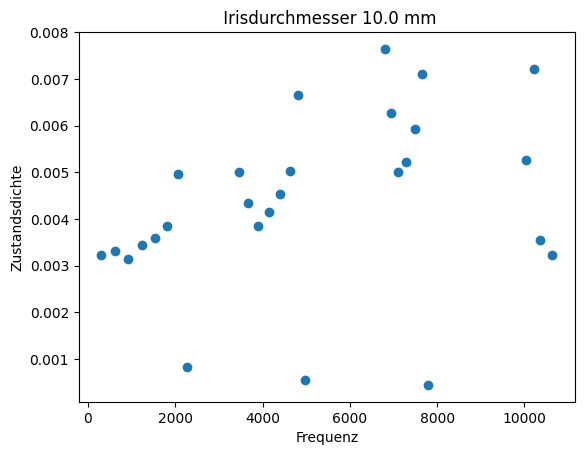

31 31


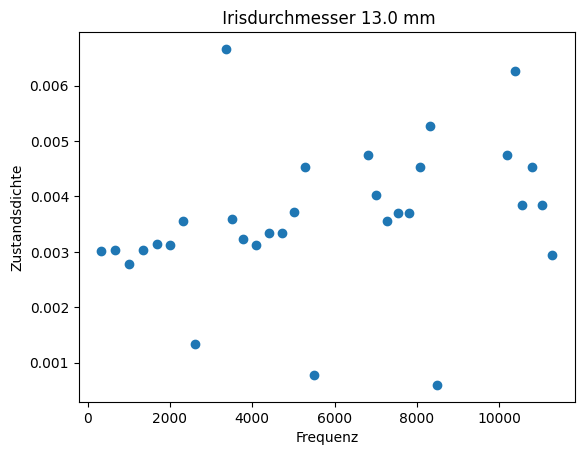

32 32


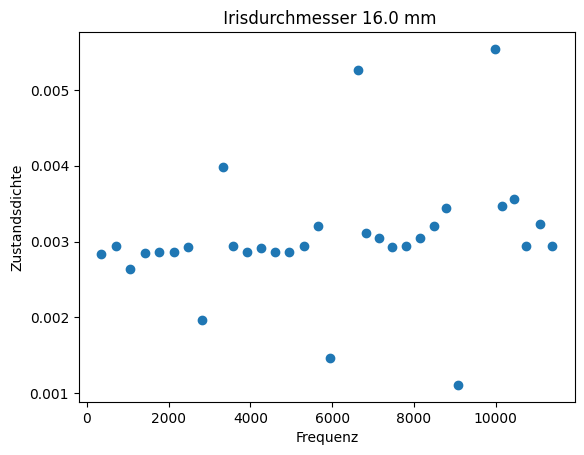

In [ ]:
def zustandsdichte(a, b):
    return 1/(b - a)

for j in range(len(peaks3_all_raw)):
    dichte3 = [] 

    for i in range(len(peaks3_all_raw[j]) - 1):
        a = peaks3_all_raw[j][i].nominal_value
        b = peaks3_all_raw[j][i+1].nominal_value
        dichte3.append(zustandsdichte(a, b))

    x = np.array([p.nominal_value for p in peaks3_all_raw[j][:-1]])

    print(np.size(x), np.size(dichte3))
    
    plt.title(f" Irisdurchmesser {iris3[j].nominal_value} mm")
    plt.scatter(x, dichte3)
    plt.xlabel("Frequenz")
    plt.ylabel("Zustandsdichte")
    plt.show()


### für Werte aus Aufgabe 4

10 10


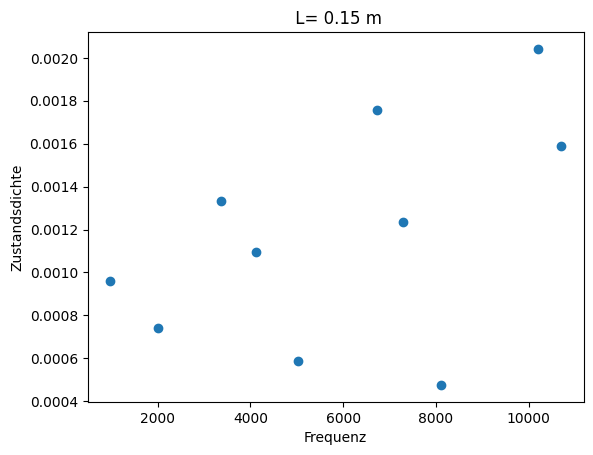

23 23


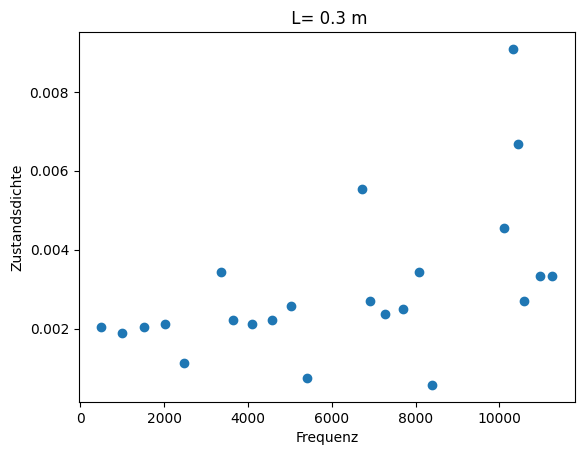

32 32


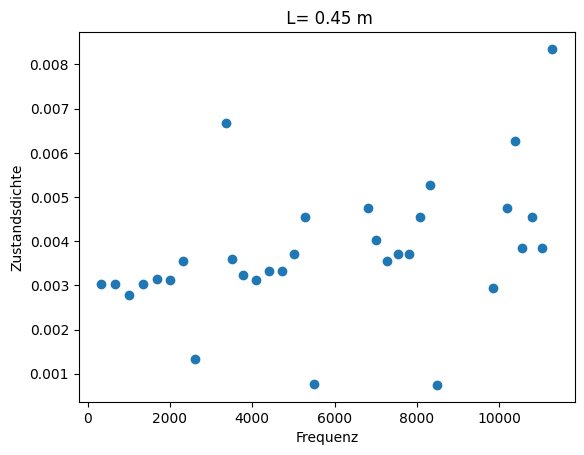

38 38


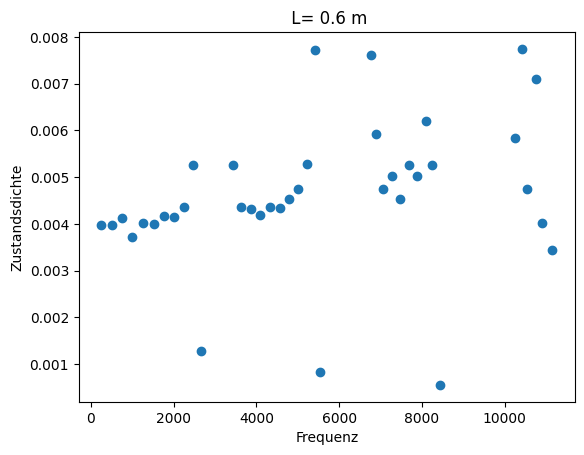

In [ ]:
for j in range(len(peaks4_all_raw)):
    dichte4 = [] 

    for i in range(len(peaks4_all_raw[j]) - 1):
        a = peaks4_all_raw[j][i].nominal_value
        b = peaks4_all_raw[j][i+1].nominal_value
        dichte4.append(zustandsdichte(a, b))

    x = np.array([p.nominal_value for p in peaks4_all_raw[j][:-1]])
    
    plt.title(f" L= {längen[j].nominal_value} m")
    plt.scatter(x, dichte4)
    plt.xlabel("Frequenz")
    plt.ylabel("Zustandsdichte")
    plt.show()

### Aufgabe 8


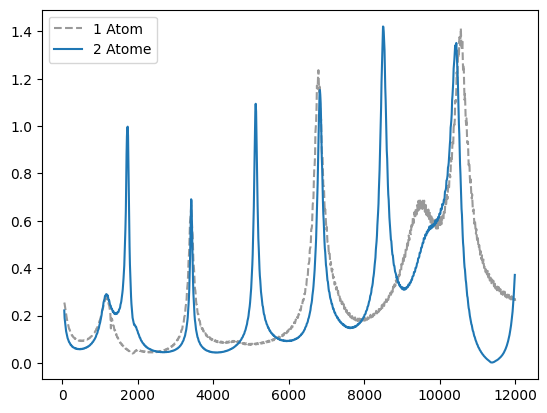

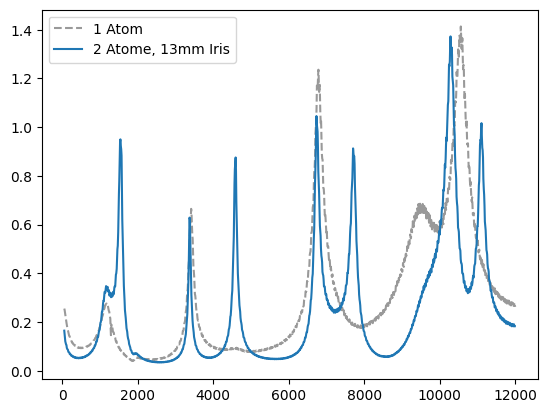

In [ ]:
files8= [r"20-03-26\8-1.dat" , r"20-03-26\8-2.dat" , r"20-03-26\8-2-13mm.dat"] 

df_one_atom= pd.read_csv(r"20-03-26\8-1.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
amplitude_one_atom= df_one_atom["Amplitude"] / df_ref["Amplitude"] 

df_two_atoms= pd.read_csv(r"20-03-26\8-2.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
amplitude_two_atoms= df_two_atoms["Amplitude"] / df_ref["Amplitude"] 

df_two_atoms_13mm= pd.read_csv(r"20-03-26\8-2-13mm.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
amplitude_two_atoms_13mm= df_two_atoms_13mm["Amplitude"] / df_ref["Amplitude"]

plt.plot(df_one_atom["Frequenz"], amplitude_one_atom, label="1 Atom", linestyle="--", color="gray", alpha= 0.8)
plt.plot(df_two_atoms["Frequenz"], amplitude_two_atoms, label="2 Atome")
plt.legend()
plt.show()

plt.plot(df_one_atom["Frequenz"], amplitude_one_atom, label="1 Atom", linestyle="--", color="gray", alpha= 0.8)
plt.plot(df_two_atoms_13mm["Frequenz"], amplitude_two_atoms_13mm, label="2 Atome, 13mm Iris")
plt.legend()
plt.show()


### Aufgabe 9 

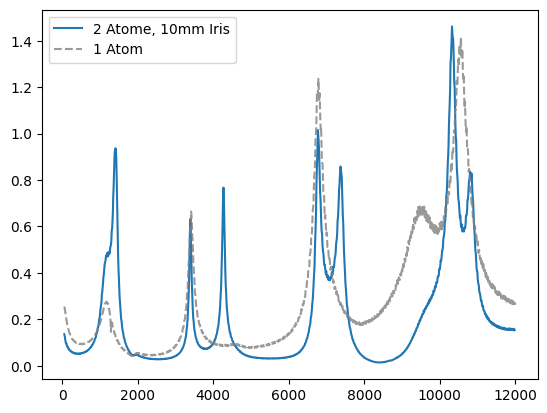

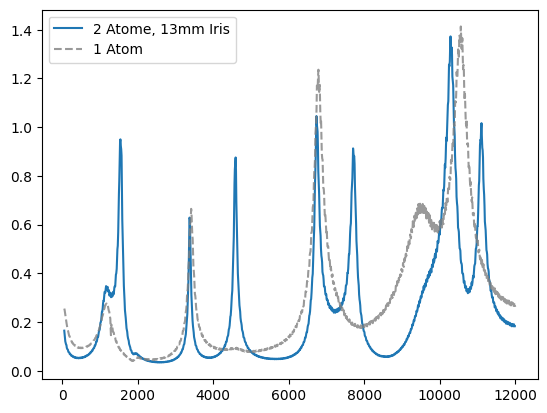

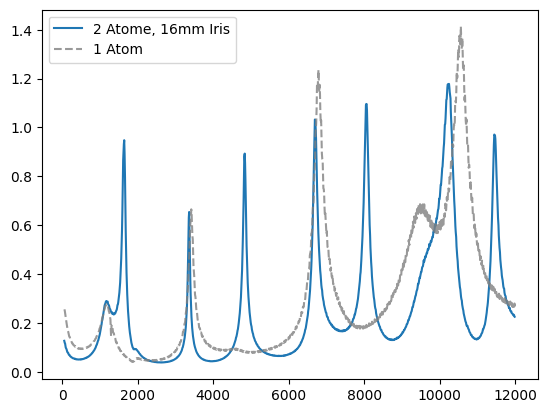

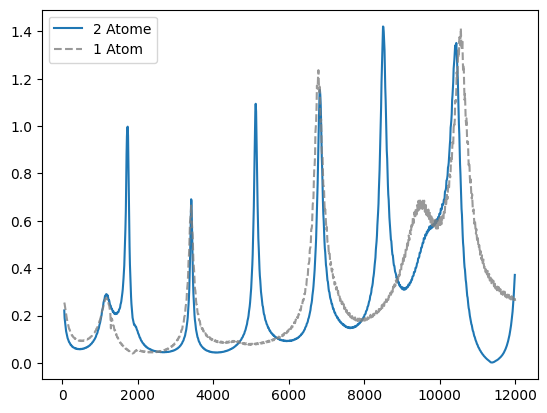

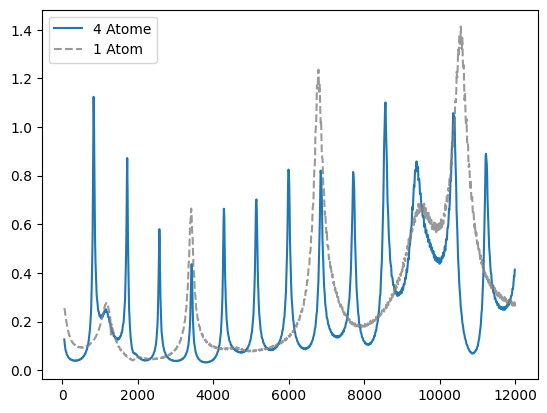

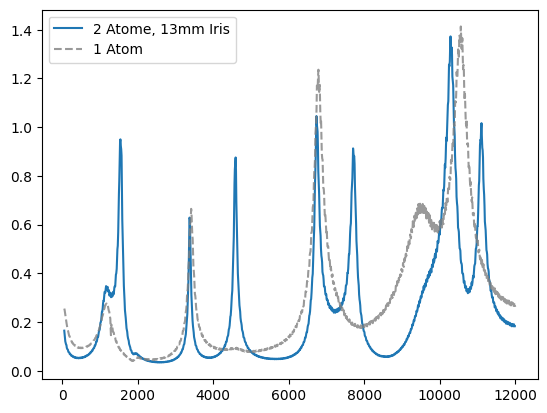

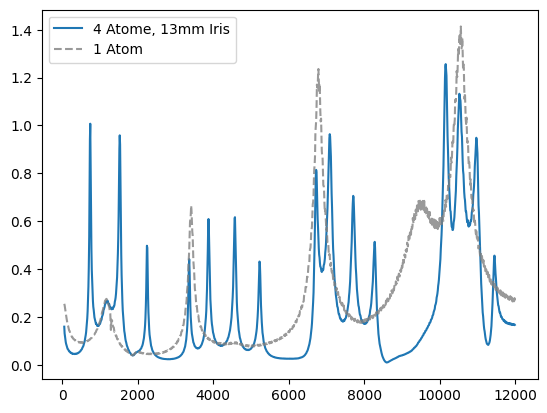

In [ ]:


files9a= [r"20-03-26\9-2-10mm.dat", r"20-03-26\8-2-13mm.dat", r"20-03-26\9-2-16mm.dat"]
labela = ["2 Atome, 10mm Iris", "2 Atome, 13mm Iris", "2 Atome, 16mm Iris"]

files9b = [r"20-03-26\8-2.dat", r"20-03-26\9-4.dat"]
labelb= ["2 Atome", "4 Atome"]

files9c= [r"20-03-26\8-2-13mm.dat" , r"20-03-26\9-4-13mm.dat"]
labelc= ["2 Atome, 13mm Iris", "4 Atome, 13mm Iris"]

for file in files9a:
    df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    frequency= df["Frequenz"]
    amplitude= df["Amplitude"] / df_ref["Amplitude"] 
    plt.plot(frequency, amplitude, label=labela[files9a.index(file)])
    plt.plot(df_one_atom["Frequenz"], amplitude_one_atom, label="1 Atom", linestyle="--", color="gray", alpha= 0.8) 
    plt.legend()
    plt.show()

for file in files9b:
    df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    frequency= df["Frequenz"]
    amplitude= df["Amplitude"] / df_ref["Amplitude"] 
    plt.plot(frequency, amplitude, label=labelb[files9b.index(file)]) 
    plt.plot(df_one_atom["Frequenz"], amplitude_one_atom, label="1 Atom", linestyle="--", color="gray", alpha= 0.8)   
    plt.legend()
    plt.show()

for file in files9c:
    df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    frequency= df["Frequenz"]
    amplitude= df["Amplitude"] / df_ref["Amplitude"] 
    plt.plot(frequency, amplitude, label=labelc[files9c.index(file)]) 
    plt.plot(df_one_atom["Frequenz"], amplitude_one_atom, label="1 Atom", linestyle="--", color="gray", alpha= 0.8)   
    plt.legend()
    plt.show()

### Aufgabe 10

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


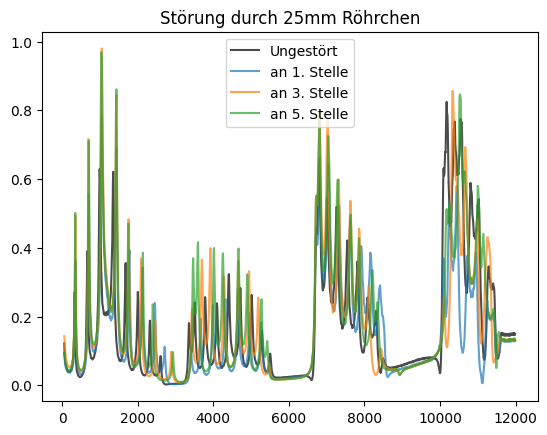

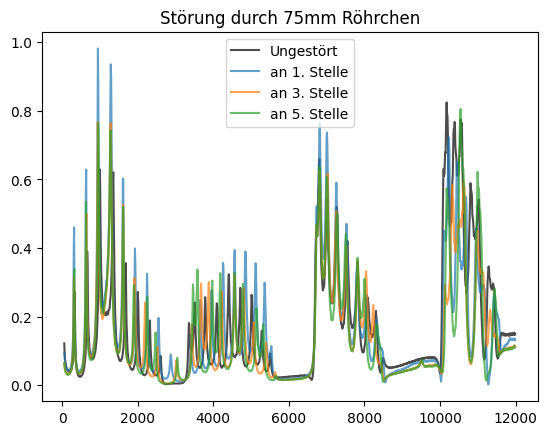

In [11]:
#Vergleich der Spekten 

df_ungestört= pd.read_csv(r"20-03-26\3-13mm.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
amplitude_ungestört= df_ungestört["Amplitude"] / df_ref["Amplitude"]

files10a= [r"20-03-26\10-25-1.dat", r"20-03-26\10-25-3.dat", r"20-03-26\10-25-5.dat"]
label10a= [ufloat(1,0), ufloat(3,0), ufloat(5,0)]

files10b =[r"20-03-26\10-75-1.dat" , r"20-03-26\10-75-3.dat", r"20-03-26\10-75-5.dat"]
label10b= [ufloat(1,0), ufloat(3,0), ufloat(5,0)]

plt.plot(df_ungestört["Frequenz"], amplitude_ungestört, label="Ungestört", alpha=0.7, color= "black")
for file in files10a:
    df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    frequency= df["Frequenz"]
    amplitude= df["Amplitude"] / df_ref["Amplitude"] 
    plt.plot(frequency, amplitude, label= f"an {label10a[files10a.index(file)].nominal_value:.0f}. Stelle", alpha=0.7)
    plt.title("Störung durch 25mm Röhrchen")  
    plt.legend()
plt.show()

plt.plot(df_ungestört["Frequenz"], amplitude_ungestört, label="Ungestört", alpha=0.7, color= "black")     
for file in files10b:
    df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    frequency= df["Frequenz"]
    amplitude= df["Amplitude"] / df_ref["Amplitude"] 
    plt.plot(frequency, amplitude, label= f"an {label10b[files10b.index(file)].nominal_value:.0f}. Stelle", alpha=0.7)
    plt.title("Störung durch 75mm Röhrchen")  
    plt.legend()
plt.show()

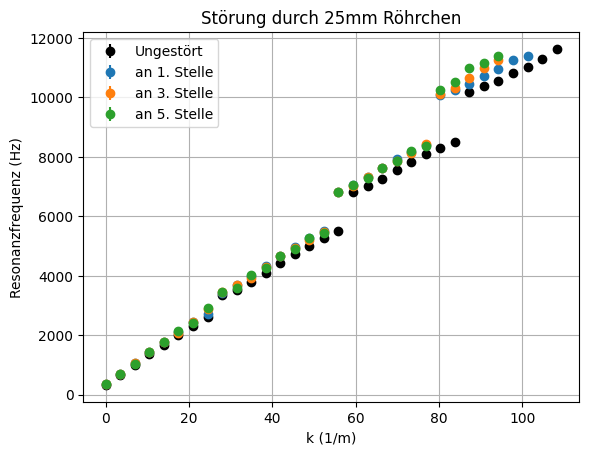

In [25]:
# Dispersionsrelation 

peaks_all_f10a, peaks_index_all10a, frequency_all10a, amplitude_all10a= find_resonance_frequencies(files10a, height=0.0005, rel_heigth= 0.2, prominence=0.009, width= (1,20))
plt.show()

for i in range(len(peaks_all_f10a)):
    peaks_all_f10a[i]= np.delete(peaks_all_f10a[i], -1) 
    
m= np.arange(len(peaks3_all_raw[1]))
x3= m * np.pi /(2* 0.45)
plt.errorbar(x3, [peak.nominal_value for peak in peaks3_all_raw[1]], yerr= 5, label= f"Ungestört", color= "black", fmt= "o")

for i in range(len(peaks_all_f10a)):
    n= np.arange(len(peaks_all_f10a[i]))
    x= n * np.pi /(2* 0.45)
    y= np.array([p.nominal_value for p in peaks_all_f10a[i]])
    
    plt.errorbar(x, y, yerr= [p.std_dev for p in peaks_all_f10a[i]], fmt='o', label= f"an {label10a[i].nominal_value:.0f}. Stelle")
    plt.xlabel("k (1/m)")
    plt.ylabel("Resonanzfrequenz (Hz)")
    plt.title(f"Störung durch 25mm Röhrchen")
    plt.legend()
plt.grid()
plt.show()

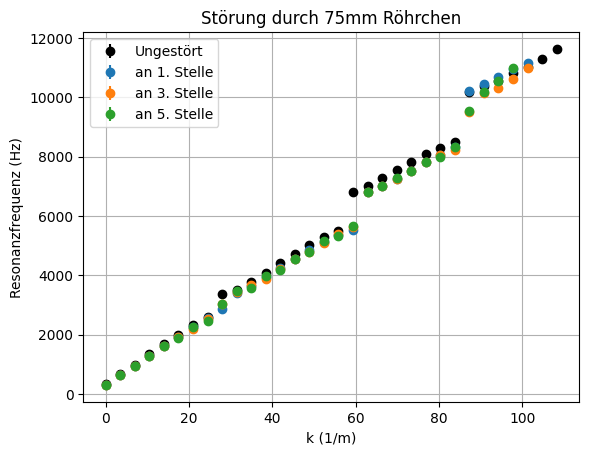

In [26]:
peaks_all_f10b, peaks_index_all10b, frequency_all10b, amplitude_all10b= find_resonance_frequencies(files10b, height=0.0005, rel_heigth= 0.2, prominence=0.009, width= (1,20))
plt.show()

for i in range(len(peaks_all_f10b)):
    peaks_all_f10b[i]= np.delete(peaks_all_f10b[i], -1) 

m= np.arange(len(peaks3_all_raw[1]))
x3= m * np.pi /(2* 0.45)
plt.errorbar(x3, [peak.nominal_value for peak in peaks3_all_raw[1]], yerr= 5, label= f"Ungestört", color= "black", fmt= "o")   

for i in range(len(peaks_all_f10b)):
    n= np.arange(len(peaks_all_f10b[i]))
    x= n * np.pi /(2* 0.45)
    y= np.array([p.nominal_value for p in peaks_all_f10b[i]])
    
    plt.errorbar(x, y, yerr= [p.std_dev for p in peaks_all_f10b[i]], fmt='o', label= f"an {label10b[i].nominal_value:.0f}. Stelle")
    plt.xlabel("k (1/m)")
    plt.ylabel("Resonanzfrequenz (Hz)")
    plt.title(f"Störung durch 75mm Röhrchen")
    plt.legend()
plt.grid()
plt.show()